# Новые манёвры и спектр: технически остановленная матрица

**Статус:** замороженный предел 30 минут на один поток превышен на индексе 11. Полученные данные сохранены; матрица 24 × 4 **не завершена**. Notebook воспроизводит только аудит сохранённых файлов и описательную статистику 15 завершённых потоков. Нельзя считать её оценкой переносимости полного заранее заданного плана. Подробности — в `UNSEEN_MANOEUVRES_REPORT.md`.

## Протокол и происхождение

Два новых физических полёта X500 записаны из Gazebo: набор/снижение с поворотом и изменением скорости; сближение/удаление с последующим боковым движением. Источник broadband — прежний контроль. Второй источник — заранее определённый синтетический нестационарный гармонический сигнал; это проверка рассогласования спектра, **не** новая реальная запись БПЛА. Настройки GCC, SRP и трекера заморожены в `UNSEEN_MANOEUVRES_PROTOCOL_MANIFEST.json`. Единица отчёта — полный аудиопоток. Условную ошибку всегда читать вместе с доступностью.

In [1]:
from pathlib import Path
import os, sys, json
project=Path.cwd()
if not (project/'results').exists():project=project.parent
os.chdir(project);sys.path.insert(0,str(project))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from analysis.unseen_partial_audit import verify
out=Path('results/unseen_manoeuvres_and_sources')
assert verify(out)['status']=='verified_partial'
audit=json.loads((out/'partial_audit.json').read_text())
manifest=json.loads((out/'evaluation_manifest.json').read_text())
runs=pd.read_csv(out/'partial_run_summary.csv')
shared=pd.read_csv(out/'partial_paired_shared.csv')
states=pd.DataFrame(audit['states'])
assert len(runs)==60 and len(shared)==30 and len(manifest['specs'])==24
plt.rcParams.update({'figure.figsize':(9,4.5),'font.size':10,'axes.grid':True,'grid.alpha':.25})
print('Проверено: 15/24 полных потоков, 60/96 полных треков,',audit['saved_audio_stream_count'],'сохранённых аудиопотоков')
display(states.groupby('status').agg(streams=('index','count'),saved_bearings=('bearing_saved','sum'),saved_tracks=('saved_tracker_count','sum')))

Проверено: 15/24 полных потоков, 60/96 полных треков, 18 сохранённых аудиопотоков


,streams,saved_bearings,saved_tracks
status,,,
complete,15,15,60
running,3,3,5
unstarted,6,0,0


## Фактическое движение и техническая стоимость

Позиции ниже взяты из `gazebo_state.csv`; ранее известных траекторий здесь нет. Порог wall time 1800 с был определён до обработки; индекс 11 остановил матрицу. Несбалансированный порядок завершения делает статистику точности ниже описательной.

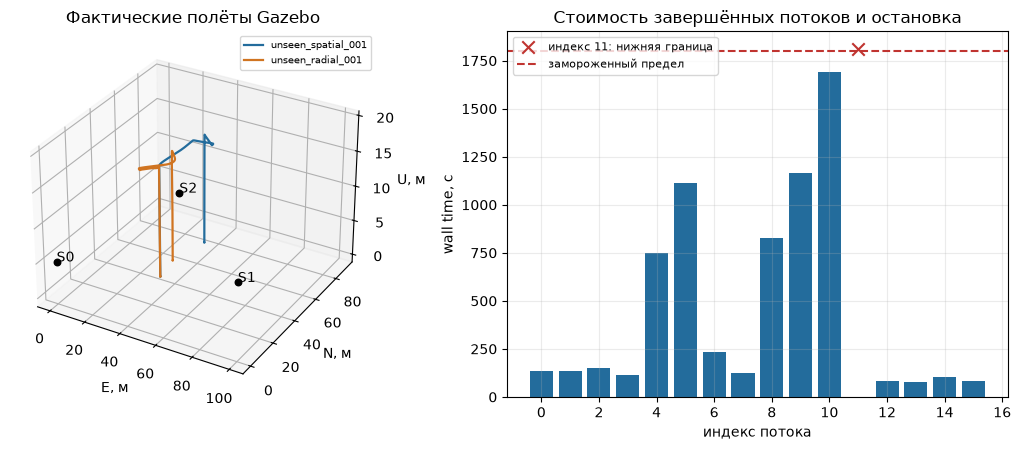

In [2]:
fig=plt.figure(figsize=(11,4.6))
ax=fig.add_subplot(121,projection='3d')
for name,color in [('unseen_spatial_001','#236C9C'),('unseen_radial_001','#D07421')]:
    df=pd.read_csv(Path('results/px4_flight')/name/'gazebo_state.csv')
    ax.plot(df.x_m,df.y_m,df.z_m,label=name,color=color,lw=1.6)
for station,xyz in [('S0',(0,0,5)),('S1',(100,0,10)),('S2',(10,90,3))]:
    ax.scatter(*xyz,color='black',s=22);ax.text(*xyz,station)
ax.set(xlabel='E, м',ylabel='N, м',zlabel='U, м',title='Фактические полёты Gazebo')
ax.legend(fontsize=7)
ax2=fig.add_subplot(122)
completed=[]
for spec in manifest['specs']:
    d=next((out/'runs').glob(f"{spec['index']:02d}_*"),None)
    if d and (d/'summary.json').exists():
        completed.append((spec['index'],json.loads((d/'summary.json').read_text())['stream_wall_s']))
ax2.bar([x for x,y in completed],[y for x,y in completed],color='#236C9C')
ax2.scatter([11],[audit['completed_stream_wall_s_max']*0+1812],color='#C03430',marker='x',s=80,label='индекс 11: нижняя граница')
ax2.axhline(1800,color='#C03430',ls='--',label='замороженный предел')
ax2.set(xlabel='индекс потока',ylabel='wall time, с',title='Стоимость завершённых потоков и остановка')
ax2.legend(fontsize=8)
plt.tight_layout();plt.show()

## Только завершённые последовательности

Показатели ниже охватывают 15 завершённых потоков в каждом варианте. Поскольку отсутствуют почти все радиальные гармонические сценарии и часть 1000 м, сравнение классов источника и манёвров на них недопустимо. Неподтверждённые потоки остаются в знаменателях подтверждения и доступности завершённой части; прерванные потоки показаны отдельно выше.

In [3]:
g=[]
for (method,variant),d in runs.groupby(['estimator_variant','confirmation_variant']):
    g.append({'method':method,'variant':variant,'completed_streams':len(d),
              'confirmed':int(d.ever_confirmed.sum()),
              'first_error_gt50m':int(d.severe_first_confirmation_over_50m.sum()),
              'availability_all_planned':d.valid_publication_count.sum()/d.publication_count.sum(),
              'median_conditional_P95_m':d.position_p95_m_conditional.median(),
              'pooled_position_95_coverage':d.position_covered_count.sum()/d.valid_publication_count.sum(),
              'nominal_5m_fraction_all':d.nominal_5m_count.sum()/d.publication_count.sum(),
              'fits_all_generations':int(d.total_executed_optimizations.sum())})
summary=pd.DataFrame(g)
display(summary.round(3))
assert (summary.completed_streams==15).all()

,method,variant,completed_streams,confirmed,first_error_gt50m,availability_all_planned,median_conditional_P95_m,pooled_position_95_coverage,nominal_5m_fraction_all,fits_all_generations
0,all_6_equal_gcc_wls,baseline,15,8,3,0.476,16.757,0.940,0.079,987
1,all_6_equal_gcc_wls,three_station_confirmation,15,8,1,0.456,15.499,0.942,0.079,1085
2,equal_weight_srp_phat,baseline,15,10,3,0.539,36.931,0.856,0.080,927
3,equal_weight_srp_phat,three_station_confirmation,15,10,3,0.519,38.580,0.826,0.080,994


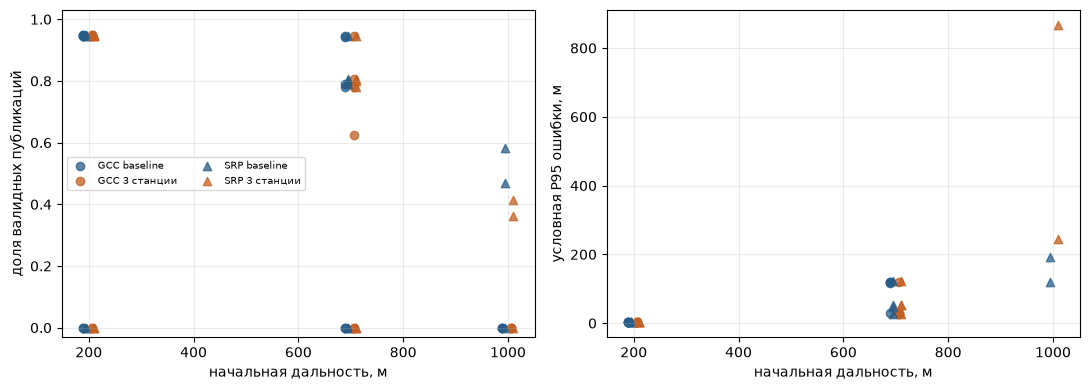

In [4]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
labels={'all_6_equal_gcc_wls':'GCC','equal_weight_srp_phat':'SRP'}
colors={'baseline':'#285C87','three_station_confirmation':'#C45F21'}
for (method,variant),d in runs.groupby(['estimator_variant','confirmation_variant']):
    jitter=(-.08 if variant=='baseline' else .08)+(-.025 if method.startswith('all_6') else .025)
    lab=labels[method]+' '+('baseline' if variant=='baseline' else '3 станции')
    axes[0].scatter(d.distance_m+jitter*100,d.availability_fraction,label=lab,color=colors[variant],
                    marker='o' if method.startswith('all_6') else '^',alpha=.75)
    axes[1].scatter(d.distance_m+jitter*100,d.position_p95_m_conditional,label=lab,color=colors[variant],
                    marker='o' if method.startswith('all_6') else '^',alpha=.75)
axes[0].set(xlabel='начальная дальность, м',ylabel='доля валидных публикаций',ylim=(-.03,1.03))
axes[1].set(xlabel='начальная дальность, м',ylabel='условная P95 ошибки, м')
axes[0].legend(fontsize=7,ncol=2)
plt.tight_layout();plt.show()

## Общие валидные эпохи

Таблица сравнивает baseline и подтверждение тремя станциями только в те моменты, когда **оба** варианта публикуют валидную оценку. Собственная доступность вариантов показана выше; общая выборка не заменяет полный знаменатель. Эпохи внутри потока зависимы.

In [5]:
shared_summary=[]
for method,d in shared.groupby('estimator_variant'):
    shared_summary.append({'method':method,'complete_pairs':len(d),'shared_valid_epochs':int(d.shared_valid_count.sum()),
                           'baseline_only_epochs':int(d.baseline_only_valid_count.sum()),
                           'new_only_epochs':int(d.new_only_valid_count.sum()),
                           'median_baseline_shared_error_m':d.baseline_shared_position_error_m_median.median(),
                           'median_new_shared_error_m':d.new_shared_position_error_m_median.median(),
                           'median_baseline_shared_coverage':d.baseline_shared_coverage.median(),
                           'median_new_shared_coverage':d.new_shared_coverage.median()})
display(pd.DataFrame(shared_summary).round(3))

,method,complete_pairs,shared_valid_epochs,baseline_only_epochs,new_only_epochs,median_baseline_shared_error_m,median_new_shared_error_m,median_baseline_shared_coverage,median_new_shared_coverage
0,all_6_equal_gcc_wls,15,1188,52,0,6.327,6.327,0.984,0.949
1,equal_weight_srp_phat,15,1345,60,9,12.376,12.376,0.953,0.953


## Граница вывода

Четыре заранее поставленных вопроса о переносе пользы подтверждения, уязвимости к манёвру/спектру, покрытии covariance и флаге 5 м **не получают окончательного ответа** при технически остановленной матрице. Приведённые числа описывают только завершённые случаи. Следующий этап — отдельное, заново замороженное исследование вычислительной стоимости или заранее разрешённый больший лимит; настройки точности по этим результатам не меняются. Редкие отказы и P99/P99.9 по двум шумовым реализациям не оцениваются.